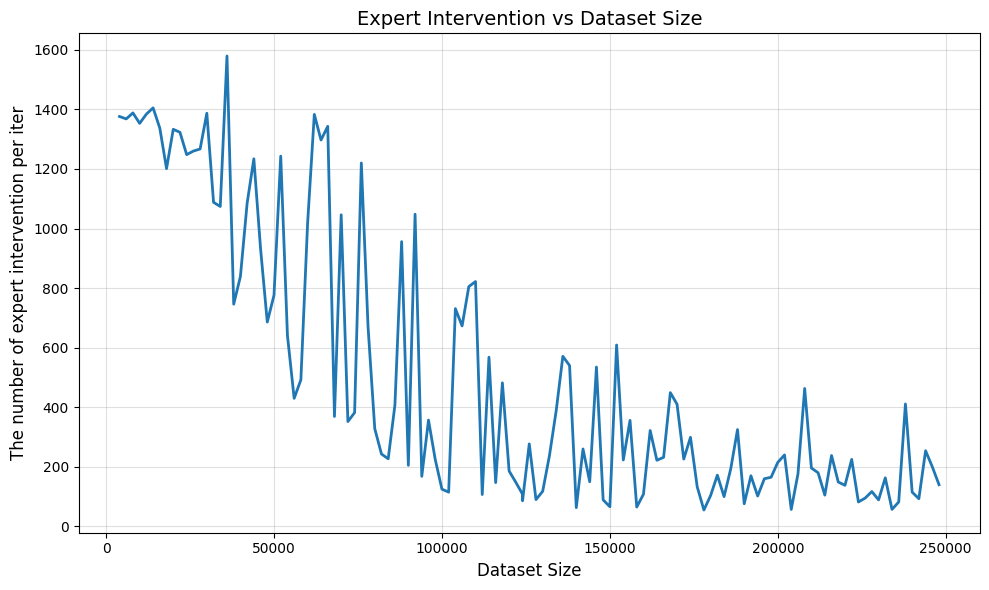

In [1]:
import json
import os
import matplotlib.pyplot as plt

def plot_nswitch_from_checkpoint(checkpoint_root):
    """
    checkpoint_root 예:
    /AILAB-summer-school-2025/RND/checkpoints/rnd_iter100_lambda0.25_minDemo70_H0_FTrue
    """

    result_path = os.path.join(checkpoint_root, "results.json")

    if not os.path.exists(result_path):
        raise FileNotFoundError(f"results.json not found: {result_path}")

    # -------------------------------
    # 1. Load results.json
    # -------------------------------
    with open(result_path, "r") as f:
        results = json.load(f)

    dataset_sizes = results["dataset_sizes"]
    nswitches = results["nswitches"]

    if len(dataset_sizes) != len(nswitches):
        raise ValueError("Length mismatch: dataset_sizes and nswitches")

    # -------------------------------
    # 2. Plot
    # -------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(dataset_sizes, nswitches, linewidth=2)

    plt.xlabel("Dataset Size", fontsize=12)
    plt.ylabel("The number of expert intervention per iter", fontsize=12)
    plt.title("Expert Intervention vs Dataset Size", fontsize=14)

    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


# ===============================
# ✅ 사용 예시
# ===============================
checkpoint_dir = "/AILAB-summer-school-2025/RND/checkpoints/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue"
plot_nswitch_from_checkpoint(checkpoint_dir)
